### Lab 7
#### 7.8.1 Polynomial Regression and Step Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [5]:
wage = pd.read_csv("data/Wage.csv")

model_raw = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
print("--- Row polinomial ---")
print(model_raw.summary())

--- Row polinomial ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     70.69
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.77e-57
Time:                        13:41:36   Log-Likelihood:                -15315.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2995   BIC:                         3.067e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -184.1542     

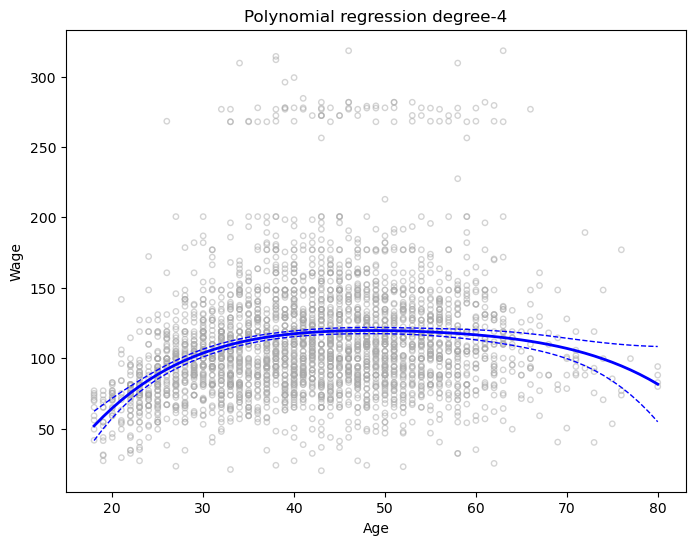

In [8]:
age_grid = pd.DataFrame({"age": np.arange(wage.age.min(), wage.age.max() + 1)})

predictions = model_raw.get_prediction(age_grid)
pred_summary = predictions.summary_frame(alpha=0.05)

plt.figure(figsize=(8, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, pred_summary["mean"], color="blue", lw=2, label="Degree-4 Polynomial")
plt.plot(age_grid.age, pred_summary["mean_ci_lower"], color="blue", linestyle="--", lw=1)
plt.plot(age_grid.age, pred_summary["mean_ci_upper"], color="blue", linestyle="--", lw=1)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Polynomial regression degree-4")
plt.show()

Based on the chart and calculated table above, we can draw next conclusions:
- The model captured the underlying trend and generated a smooth curve through the data point cloud
- the train accuracy is quite low $R^2=0.086$, only 8% of wage variance was explained
- Three features (age, $age^2$, and $age^3$) turned out to be statistically significant
- The 4th-degree polynomial term is strictly non-significant at the 5% level ($p = 0.051$)
- The confidence intervals widen at both tails of the curve due to less data density at the age extremes

In [12]:
wage["age_bins"] = pd.cut(wage.age, bins=4)

print("\n--- Bins distribution ---")
print(wage["age_bins"].value_counts().sort_index())

model_bins = smf.ols(formula="wage ~ age_bins", data=wage).fit()
print("\n--- The step function result ---")
print(model_bins.summary().tables[1])


--- Bins distribution ---
age_bins
(17.938, 33.5]     750
(33.5, 49.0]      1399
(49.0, 64.5]       779
(64.5, 80.0]        72
Name: count, dtype: int64

--- The step function result ---
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           94.1584      1.476     63.790      0.000      91.264      97.053
age_bins[T.Interval(33.5, 49.0, closed='right')]    24.0535      1.829     13.148      0.000      20.466      27.641
age_bins[T.Interval(49.0, 64.5, closed='right')]    23.6646      2.068     11.443      0.000      19.610      27.719
age_bins[T.Interval(64.5, 80.0, closed='right')]     7.6406      4.987      1.532      0.126      -2.139      17.420


After performing step function on the full data set we can clearly see that, the feature Age was divided on 4 groups (dummy variable). The youngest age group was automatically selected as the reference (baseline) category

The baseline mean wage for the youngest group (ages 17.9 to 33.5) is 94.16. As age increases, the first significant shift occurs in the second group (ages 33.5 to 49.0), increasing the mean wage by 24.05 to a total of 118.21, and so on

The oldest age group (ages 64.5 to 80.0) shows the smallest mean increase (7.64), which is statistically indistinguishable from the baseline group ($p = 0.126$)

In [15]:
from statsmodels.stats.anova import anova_lm

fit_1 = smf.ols(formula="wage ~ age", data=wage).fit()
fit_2 = smf.ols(formula="wage ~ age + I(age**2)", data=wage).fit()
fit_3 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3)", data=wage).fit()
fit_4 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
fit_5 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4) + I(age**5)", data=wage).fit()

anova_results = anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5)
print(anova_results)

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


The ANOVA analysis showed:

The 4th-degree polynomial model is on the verge of statistical significance ($p \approx 0.051$).

While the 2nd-degree polynomial provides the largest marginal improvement in fit ($F = 143.59$), the sequential ANOVA test suggests that the cubic (3rd-degree) term is still highly statistically significant ($p = 0.0017$). Therefore, a 3rd or 4th-degree polynomial should be preferred to avoid underfitting

#### 7.8.2 Splines

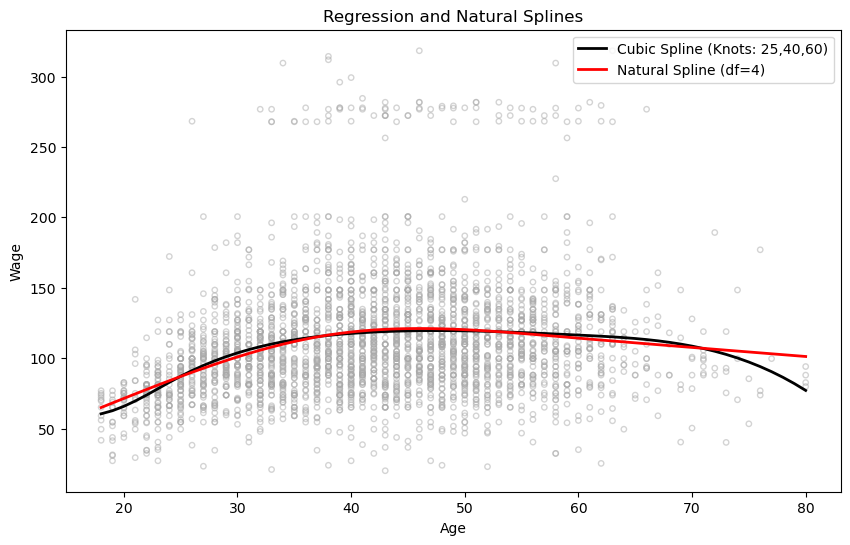

In [21]:
age_grid = pd.DataFrame({'age': np.arange(wage.age.min(), wage.age.max() + 1)})

# cubic spline with knots - 25, 40, 60
fit_cubic = smf.ols(formula="wage ~ bs(age, knots=(25, 40, 60), degree=3)", data=wage).fit()
preds_cubic = fit_cubic.get_prediction(age_grid).summary_frame()

# 2. natural spline with df=4
fit_natural = smf.ols(formula="wage ~ cr(age, df=4)", data=wage).fit()
preds_natural = fit_natural.get_prediction(age_grid).summary_frame()

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, preds_cubic["mean"], color="black", lw=2, label="Cubic Spline (Knots: 25,40,60)")
plt.plot(age_grid.age, preds_natural["mean"], color="red", lw=2, label="Natural Spline (df=4)")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Regression and Natural Splines")
plt.legend()
plt.show()

The Natural Spline exhibits a linear behavior at the boundaries because of its inherent constraints: the function is forced to be linear for values of X smaller than the leftmost knot or larger than the rightmost knot

This boundary constraint effectively reduces the variance at the extremes. In contrast, the standard Cubic Spline lacks these constraints, making its tails unstable and prone to high variance in regions with sparse data

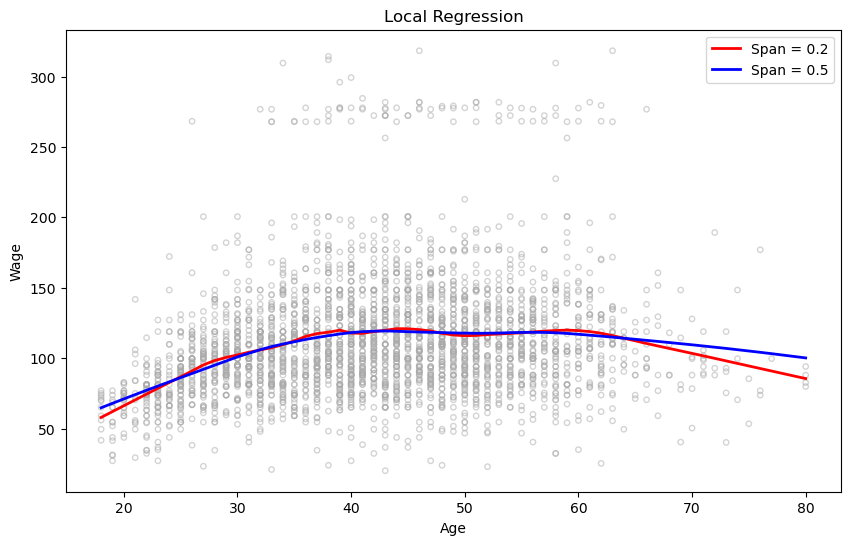

In [22]:
from statsmodels.nonparametric.smoothers_lowess import lowess

lowess_02 = lowess(wage.wage, wage.age, frac=0.2, it=0)
lowess_05 = lowess(wage.wage, wage.age, frac=0.5, it=0)

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(lowess_02[:, 0], lowess_02[:, 1], color='red', lw=2, label="Span = 0.2")
plt.plot(lowess_05[:, 0], lowess_05[:, 1], color="blue", lw=2, label="Span = 0.5")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Local Regression")
plt.legend()
plt.show()

The local regression model with a span of 0.2 displays a more fluctuating shape. It has a higher variance, which increases the risk of overfitting to local noise

first glance, both models successfully capture the overarching macro-trend, but the span of 0.5 offers a much more stable and robust generalization

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
C:\Users\ilyas\AppData\Local\Temp\ipykernel_2764\2253973587.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_cv.summary()


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                       5.644
Link Function:                     IdentityLink Log Likelihood:                                -15312.6161
Number of Samples:                         3000 AIC:                                              30638.52
                                                AICc:                                            30638.554
                                                GCV:                                             1596.8792
                                                Scale:                                             39.8933
                                                Pseudo R-Squared:                                   0.0874
Feature Function                  Lam

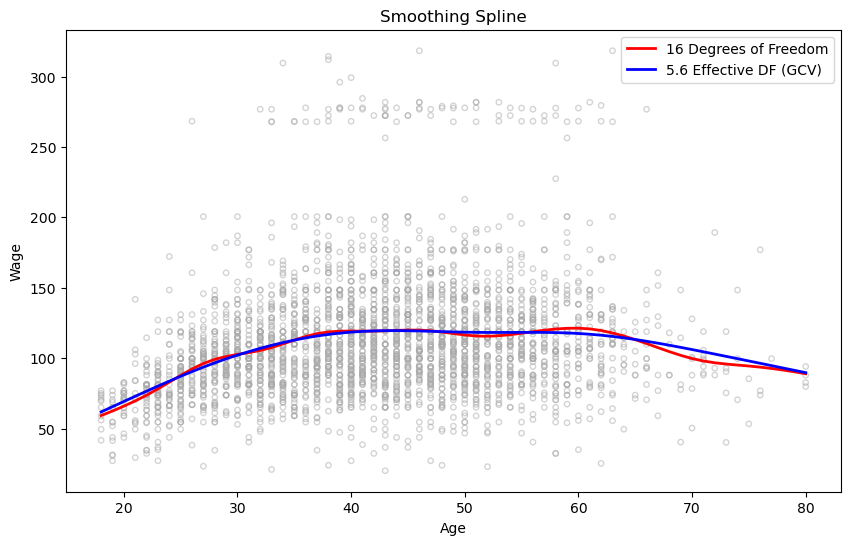

In [35]:
from pygam import LinearGAM, s

X = wage["age"].values.reshape(-1, 1)
y = wage["wage"].values

gam_16 = LinearGAM(s(0, n_splines=16)).fit(X, y)

gam_cv = LinearGAM(s(0)).gridsearch(X, y)

gam_cv.summary()

age_grid_vals = age_grid["age"].values.reshape(-1, 1)
pred_16 = gam_16.predict(age_grid_vals)
pred_cv = gam_cv.predict(age_grid_vals)

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, pred_16, color="red", lw=2, label="16 Degrees of Freedom")
plt.plot(age_grid.age, pred_cv, color="blue", lw=2, label=f'{gam_cv.statistics_["edof"]:.1f} Effective DF (GCV)')
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Smoothing Spline")
plt.legend()
plt.show()

The curve generated by the smoothing spline with 5.6 effective degrees of freedom (EDoF) exhibits a more stable and generalized trend

A smaller number of effective degrees of freedom restricts model flexibility, thereby minimizing variance

As shown in the chart, a higher degree of freedom ($df=16$) causes the model to capture local noise, leading to artificial fluctuations and a higher risk of overfitting. This is especially true for this dataset, where the underlying macro-relationship is relatively simple and smooth

#### 7.8.3 GAMs

--- ANOVA TABLE ---
   df_resid           ssr  df_diff      ss_diff          F    Pr(>F)
0    2991.0  3.717318e+06      0.0          NaN        NaN       NaN
1    2990.0  3.700612e+06      1.0  16706.49743  13.495266  0.000243
2    2988.0  3.699002e+06      2.0   1609.69955   0.650146  0.522043


C:\Users\ilyas\AppData\Local\Temp\ipykernel_2764\3652321696.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")


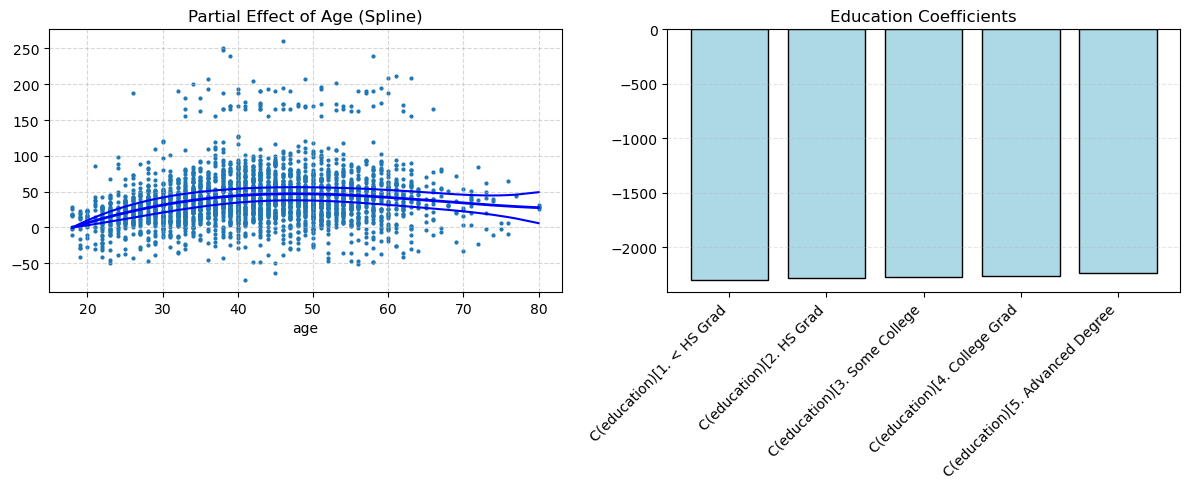

In [47]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

gam_m1 = smf.ols(formula="wage ~ cr(age, df=5) + C(education)", data=wage).fit()
gam_m2 = smf.ols(formula="wage ~ year + cr(age, df=5) + C(education)", data=wage).fit()
gam_m3 = smf.ols(formula="wage ~ cr(year, df=4) + cr(age, df=5) + C(education)", data=wage).fit()

print("--- ANOVA TABLE ---")
print(anova_lm(gam_m1, gam_m2, gam_m3))


x_spline = wage[["age"]]
bs = BSplines(x_spline, df=[5], degree=[3])

from patsy import dmatrix
X_linear = dmatrix("year + C(education) -1", data=wage, return_type="dataframe")

gam_model = GLMGam(wage["wage"], exog=X_linear, smoother=bs).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gam_model.plot_partial(smooth_index=0, ax=axes[0], cpr=True)
axes[0].set_title("Partial Effect of Age (Spline)")
axes[0].grid(True, linestyle="--", alpha=0.5)

edu_coefs = gam_model.params[gam_model.params.index.str.contains("education")]
edu_labels = [label.split("[T.")[-1].split("]")[0] for label in edu_coefs.index]

axes[1].bar(edu_labels, edu_coefs.values, color="lightblue", edgecolor="black")
axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")
axes[1].set_title("Education Coefficients")
axes[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Incorporating a linear term for 'year' (Model 2) into the base model significantly improves the fit ($F = 13.50, p = 0.00024$)

Upgrading 'year' to a non-linear natural spline (Model 3) does not make statistical sense, as the F-statistic drops sharply ($F = 0.65$) and the p-value is highly non-significant ($p = 0.522$)

--- ANOVA TABLE ---
   df_resid           ssr  df_diff      ss_diff          F    Pr(>F)
0    2991.0  3.717318e+06      0.0          NaN        NaN       NaN
1    2990.0  3.700612e+06      1.0  16706.49743  13.495266  0.000243
2    2988.0  3.699002e+06      2.0   1609.69955   0.650146  0.522043


C:\Users\ilyas\AppData\Local\Temp\ipykernel_2764\1590433225.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")


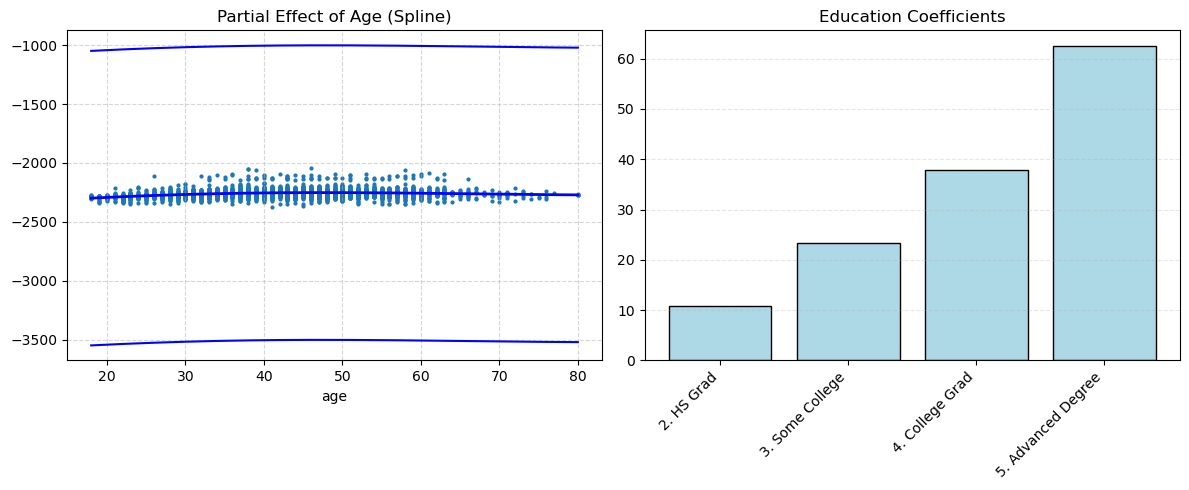

In [48]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

gam_m1 = smf.ols(formula="wage ~ cr(age, df=5) + C(education)", data=wage).fit()
gam_m2 = smf.ols(formula="wage ~ year + cr(age, df=5) + C(education)", data=wage).fit()
gam_m3 = smf.ols(formula="wage ~ cr(year, df=4) + cr(age, df=5) + C(education)", data=wage).fit()

print("--- ANOVA TABLE ---")
print(anova_lm(gam_m1, gam_m2, gam_m3))


x_spline = wage[["age"]]
bs = BSplines(x_spline, df=[5], degree=[3])

from patsy import dmatrix
X_linear = dmatrix("year + C(education)", data=wage, return_type="dataframe")

gam_model = GLMGam(wage["wage"], exog=X_linear, smoother=bs).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gam_model.plot_partial(smooth_index=0, ax=axes[0], cpr=True)
axes[0].set_title("Partial Effect of Age (Spline)")
axes[0].grid(True, linestyle="--", alpha=0.5)

edu_coefs = gam_model.params[gam_model.params.index.str.contains("education")]
edu_labels = [label.split("[T.")[-1].split("]")[0] for label in edu_coefs.index]

axes[1].bar(edu_labels, edu_coefs.values, color="lightblue", edgecolor="black")
axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")
axes[1].set_title("Education Coefficients")
axes[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The wage is increasing with every new stage of educations